<a href="https://colab.research.google.com/github/njwbilll/finalterm-machine-learning/blob/main/2_regression_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Machine Learning -End-to-End Regression Pipeline
## Prediksi Tahun Rilis Lagu menggunakan Deep Learning
### Dengan Optuna, LIME, dan MLflow

**Nama:** Najwa Bilqis Al Khalidah
**NIM:** 101032300186
**Kelas:** TK-46-GAB

---
## Deskripsi Proyek

Notebook ini merupakan implementasi end-to-end pipeline deep learning untuk memprediksi
tahun rilis lagu berdasarkan fitur audio numerik (regresi). Pipeline mencakup:

1. Pemuatan dataset dari file CSV (midterm-regresi-dataset.csv)
2. Eksplorasi data (EDA) dan visualisasi distribusi target serta korelasi fitur
3. Preprocessing: imputasi missing values, penanganan outlier, dan normalisasi
4. Pembagian data menjadi set train, validasi, dan test
5. Perancangan arsitektur jaringan saraf tiruan (PyTorch) dengan BatchNorm dan Dropout
6. Hyperparameter tuning menggunakan Optuna
7. Pelatihan model final dengan early stopping dan learning rate scheduler
8. Evaluasi model menggunakan metrik regresi (MSE, RMSE, MAE, R2)
9. Interpretasi prediksi model menggunakan LIME
10. Pelacakan eksperimen menggunakan MLflow

Dataset yang digunakan: midterm-regresi-dataset.csv

In [6]:
# Instalasi library yang diperlukan
# Jalankan cell ini sekali, kemudian restart kernel jika diperlukan
!pip install torch optuna lime mlflow scikit-learn pandas numpy matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 24.7 MB/s eta 0:00:00


# 1. INSTALASI
Instalasi Library yang Dibutuhkan


In [7]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import lime
import lime.lime_tabular

import mlflow
import mlflow.pytorch

print(f"PyTorch version : {torch.__version__}")
print(f"Optuna version  : {optuna.__version__}")
print(f"MLflow version  : {mlflow.__version__}")

PyTorch version : 2.11.0+cpu
Optuna version  : 4.9.0
MLflow version  : 3.14.0


## Bagian 1: Memuat Dataset

In [8]:
import gdown

FILE_ID = "1cXdPPYlC8L1JbZzBT_-SAxqUYWjIY4IZ"
OUTPUT_PATH = "midterm-regresi-dataset.csv"

if not os.path.exists(OUTPUT_PATH):
    print("Mengunduh dataset dari Google Drive...")
    gdown.download(
        f"https://drive.google.com/uc?id={FILE_ID}",
        OUTPUT_PATH,
        quiet=False
    )
    print("Unduhan selesai.")
else:
    print("Dataset sudah tersedia di lokal, melewati unduhan.")

print(f"Ukuran file: {os.path.getsize(OUTPUT_PATH) / 1e6:.1f} MB")

Mengunduh dataset dari Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1cXdPPYlC8L1JbZzBT_-SAxqUYWjIY4IZ
From (redirected): https://drive.google.com/uc?id=1cXdPPYlC8L1JbZzBT_-SAxqUYWjIY4IZ&confirm=t&uuid=97797975-d115-4381-bbf9-e2e332f2d9f7
To: /content/midterm-regresi-dataset.csv
100%|██████████| 443M/443M [00:09<00:00, 47.8MB/s]

Unduhan selesai.
Ukuran file: 443.4 MB


In [9]:

# Dataset tidak memiliki header bawaan.
# Kolom pertama adalah target (tahun rilis lagu).
raw_df = pd.read_csv(OUTPUT_PATH, header=None)
print(f"Shape dataset mentah : {raw_df.shape}")

# Beri nama kolom
n_features = raw_df.shape[1] - 1
feature_cols = [f"feature_{i+1}" for i in range(n_features)]
target_col = "release_year"

raw_df.columns = [target_col] + feature_cols
print(f"Jumlah fitur : {n_features}")
raw_df.head(3)

Shape dataset mentah : (515345, 91)
Jumlah fitur : 90


,release_year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345


## Bagian 2: Eksplorasi Data (EDA)

In [10]:
print("--- Statistik Deskriptif ---")
display(raw_df.describe().T.head(10))

print("\n--- Missing Values ---")
missing = raw_df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value.")

--- Statistik Deskriptif ---


,count,mean,std,min,25%,50%,75%,max
release_year,515345.0,1998.397082,10.931046,1922.00000,1994.00000,2002.00000,2006.00000,2011.00000
feature_1,515345.0,43.387126,6.067558,1.74900,39.95469,44.25850,47.83389,61.97014
feature_2,515345.0,1.289554,51.580351,-337.09250,-26.05952,8.41785,36.12401,384.06573
feature_3,515345.0,8.658347,35.268585,-301.00506,-11.46271,10.47632,29.76482,322.85143
feature_4,515345.0,1.164124,16.322790,-154.18358,-8.48750,-0.65284,8.78754,335.77182
feature_5,515345.0,-6.553601,22.860785,-181.95337,-20.66645,-6.00777,7.74187,262.06887
feature_6,515345.0,-9.521975,12.857751,-81.79429,-18.44099,-11.18839,-2.38896,166.23689
feature_7,515345.0,-2.391089,14.571873,-188.21400,-10.78060,-2.04667,6.50858,172.40268
feature_8,515345.0,-1.793236,7.963827,-72.50385,-6.46842,-1.73645,2.91345,126.74127
feature_9,515345.0,3.727876,10.582861,-126.47904,-2.29366,3.82231,9.96182,146.29795



--- Missing Values ---
Tidak ada missing value.


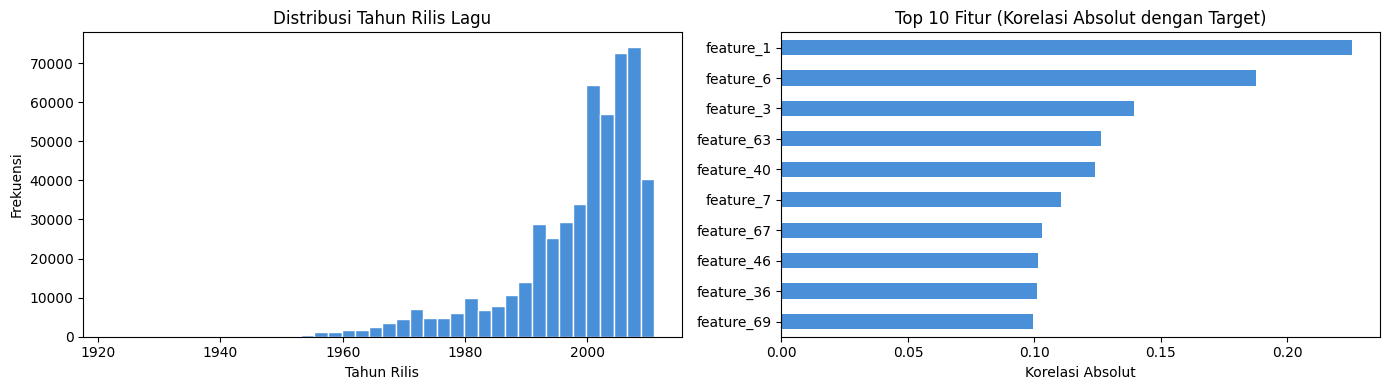

In [11]:
# Distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(raw_df[target_col], bins=40, color="#4A90D9", edgecolor="white")
axes[0].set_title("Distribusi Tahun Rilis Lagu")
axes[0].set_xlabel("Tahun Rilis")
axes[0].set_ylabel("Frekuensi")

# Korelasi top 10 fitur
corr = raw_df.corr()[target_col].drop(target_col).abs().sort_values(ascending=False)
corr.head(10).plot(kind="barh", ax=axes[1], color="#4A90D9")
axes[1].set_title("Top 10 Fitur (Korelasi Absolut dengan Target)")
axes[1].set_xlabel("Korelasi Absolut")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120)
plt.show()

## Bagian 3: Preprocessing Data

In [12]:
df = raw_df.copy()

# Imputasi missing values dengan median
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  Imputasi median pada kolom: {col}")

# Filter outlier target dengan IQR 1-99 percentile
Q1 = df[target_col].quantile(0.01)
Q3 = df[target_col].quantile(0.99)
before = len(df)
df = df[(df[target_col] >= Q1) & (df[target_col] <= Q3)]
print(f"Baris setelah filter outlier: {len(df)} (dihapus {before - len(df)})")

# Pisahkan fitur dan target
X = df[feature_cols].values.astype(np.float32)
y = df[target_col].values.astype(np.float32)

# Split data: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# Normalisasi fitur
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc   = scaler.transform(X_val).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

# Normalisasi target
y_mean, y_std = y_train.mean(), y_train.std()
y_train_n = ((y_train - y_mean) / y_std).astype(np.float32)
y_val_n   = ((y_val   - y_mean) / y_std).astype(np.float32)
y_test_n  = ((y_test  - y_mean) / y_std).astype(np.float32)

print(f"Target normalisasi: mean={y_mean:.2f}, std={y_std:.2f}")

Baris setelah filter outlier: 510415 (dihapus 4930)
Train: 357290 | Val: 76562 | Test: 76563
Target normalisasi: mean=1998.82, std=10.04


## Bagian 4: Arsitektur Model Deep Learning

In [13]:
INPUT_DIM = X_train_sc.shape[1]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


class RegressionNet(nn.Module):
    """
    Jaringan saraf tiruan untuk regresi.
    Menggunakan BatchNorm dan Dropout untuk regularisasi.
    """
    def __init__(self, input_dim, hidden_dims, dropout_rate):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout_rate)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)


def build_dataloaders(X_tr, y_tr, X_v, y_v, batch_size):
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    val_ds   = TensorDataset(torch.from_numpy(X_v),  torch.from_numpy(y_v))
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False),
    )


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(xb)
    return total / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total, preds_list = 0.0, []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            total += criterion(pred, yb).item() * len(xb)
            preds_list.append(pred.cpu().numpy())
    return total / len(loader.dataset), np.concatenate(preds_list)


print("Kelas dan fungsi helper berhasil didefinisikan.")

Device: cpu
Kelas dan fungsi helper berhasil didefinisikan.


## Bagian 5: Hyperparameter Tuning dengan Optuna

In [14]:
import optuna
from optuna.pruners import MedianPruner

N_TRIALS    = 20
TUNE_EPOCHS = 30
TUNE_SUBSET = 0.4   # Gunakan 40% dari data saat HPO

def objective(trial):
    # search space yang lebih sempit dan pintar
    n_layers     = trial.suggest_int("n_layers", 1, 3)
    hidden_dims  = [trial.suggest_categorical(f"units_l{i}", [64, 128, 256]) for i in range(n_layers)]
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.4)
    lr           = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size   = trial.suggest_categorical("batch_size", [128, 256])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    model     = RegressionNet(INPUT_DIM, hidden_dims, dropout_rate).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    # Subsample agar cepat
    n_sub = int(len(X_train_sc) * TUNE_SUBSET)
    idx   = torch.randperm(len(X_train_sc))[:n_sub]
    train_dl, val_dl = build_dataloaders(
        X_train_sc[idx], y_train_n[idx],
        X_val_sc, y_val_n,
        batch_size
    )

    best_val, patience_count = float("inf"), 0
    for step in range(TUNE_EPOCHS):
        train_one_epoch(model, train_dl, optimizer, criterion)
        val_loss, _ = evaluate(model, val_dl, criterion)

        # Pruning: laporkan ke Optuna dan stop trial jelek lebih awal
        trial.report(val_loss, step)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if val_loss < best_val:
            best_val, patience_count = val_loss, 0
        else:
            patience_count += 1
        if patience_count >= 5:
            break

    return best_val


# MedianPruner menghapus trial lebih jelek dari median setiap checkpoin
study = optuna.create_study(
    direction="minimize",
    study_name="song_year_regression",
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
print("Best params:", best_params)
print("Best val MSE:", study.best_value)

import json
with open("best_params.json", "w") as f:
    json.dump(best_params, f)

  0%|          | 0/20 [00:00<?, ?it/s]

Best params: {'n_layers': 3, 'units_l0': 256, 'units_l1': 64, 'units_l2': 128, 'dropout_rate': 0.21864582127440985, 'lr': 0.0004454943399774379, 'batch_size': 256, 'weight_decay': 1.5095611482376382e-05}
Best val MSE: 0.6057438740725677


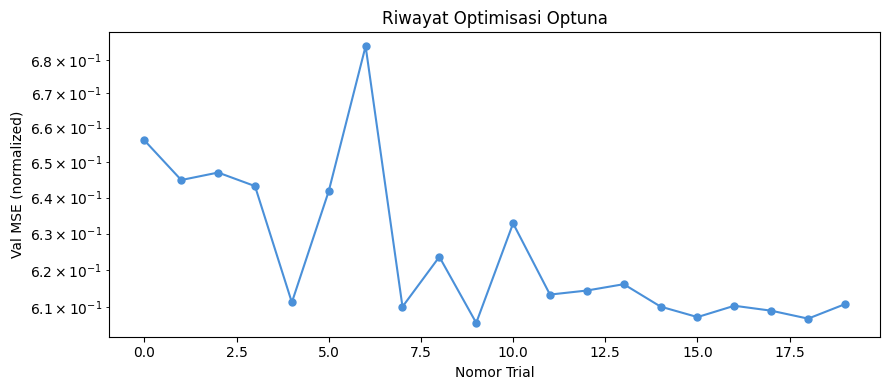

In [16]:
# Visualisasi riwayat Optuna
plt.figure(figsize=(9, 4))
plt.plot(
    [t.number for t in study.trials],
    [t.value  for t in study.trials],
    marker="o", markersize=5, color="#4A90D9"
)
plt.title("Riwayat Optimisasi Optuna")
plt.xlabel("Nomor Trial")
plt.ylabel("Val MSE (normalized)")
plt.yscale("log")
plt.tight_layout()
plt.savefig("optuna_history.png", dpi=120)
plt.show()

## Bagian 6: Pelatihan Model Final dengan MLflow Tracking

In [18]:
best_params = study.best_params
print(best_params)

{'n_layers': 3, 'units_l0': 256, 'units_l1': 64, 'units_l2': 128, 'dropout_rate': 0.21864582127440985, 'lr': 0.0004454943399774379, 'batch_size': 256, 'weight_decay': 1.5095611482376382e-05}


2026/06/23 23:00:47 INFO mlflow.tracking.fluent: Experiment with name 'Song_Year_Regression' does not exist. Creating a new experiment.


Epoch   20 | Train: 0.58643 | Val: 0.59159
Epoch   40 | Train: 0.55848 | Val: 0.58764
Epoch   60 | Train: 0.54359 | Val: 0.58799
Early stopping pada epoch 64.
Bobot terbaik dimuat.


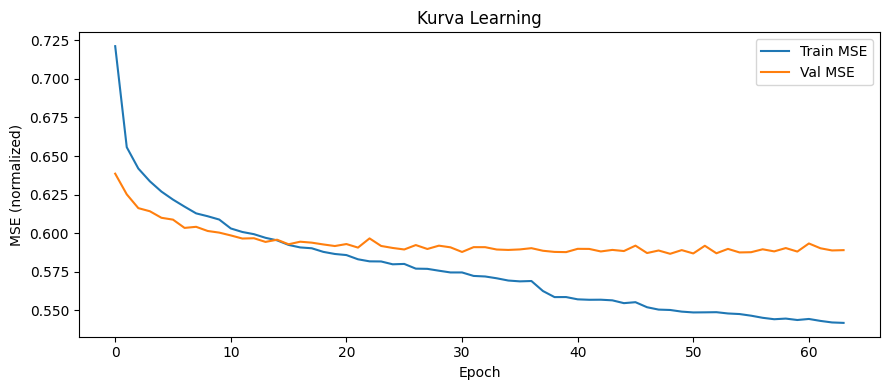

In [19]:
FINAL_EPOCHS = 150
PATIENCE      = 15

n_layers_best    = best_params["n_layers"]
hidden_dims_best = [best_params[f"units_l{i}"] for i in range(n_layers_best)]
dropout_best     = best_params["dropout_rate"]
lr_best          = best_params["lr"]
bs_best          = best_params["batch_size"]
wd_best          = best_params["weight_decay"]

mlflow.set_experiment("Song_Year_Regression")

with mlflow.start_run(run_name="DL_Regression_Final"):

    mlflow.log_params({
        "n_layers":     n_layers_best,
        "hidden_dims":  str(hidden_dims_best),
        "dropout_rate": dropout_best,
        "lr":           lr_best,
        "batch_size":   bs_best,
        "weight_decay": wd_best,
        "optimizer":    "Adam",
        "epochs":       FINAL_EPOCHS,
        "patience":     PATIENCE,
    })

    model_final = RegressionNet(INPUT_DIM, hidden_dims_best, dropout_best).to(DEVICE)
    optimizer_f = torch.optim.Adam(model_final.parameters(), lr=lr_best, weight_decay=wd_best)
    scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_f, factor=0.5, patience=5)
    criterion_f = nn.MSELoss()

    train_dl_f, val_dl_f = build_dataloaders(X_train_sc, y_train_n, X_val_sc, y_val_n, bs_best)

    history_tr, history_vl = [], []
    best_val_loss, best_state, patience_ctr = float("inf"), None, 0

    for epoch in range(1, FINAL_EPOCHS + 1):
        tr_loss = train_one_epoch(model_final, train_dl_f, optimizer_f, criterion_f)
        vl_loss, _ = evaluate(model_final, val_dl_f, criterion_f)
        scheduler.step(vl_loss)

        history_tr.append(tr_loss)
        history_vl.append(vl_loss)
        mlflow.log_metrics({"train_mse_norm": tr_loss, "val_mse_norm": vl_loss}, step=epoch)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state = {k: v.clone() for k, v in model_final.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if epoch % 20 == 0:
            print(f"Epoch {epoch:4d} | Train: {tr_loss:.5f} | Val: {vl_loss:.5f}")

        if patience_ctr >= PATIENCE:
            print(f"Early stopping pada epoch {epoch}.")
            break

    model_final.load_state_dict(best_state)
    print("Bobot terbaik dimuat.")

    # Kurva learning
    plt.figure(figsize=(9, 4))
    plt.plot(history_tr, label="Train MSE")
    plt.plot(history_vl, label="Val MSE")
    plt.title("Kurva Learning")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (normalized)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("learning_curve.png", dpi=120)
    mlflow.log_artifact("learning_curve.png")
    plt.show()

## Bagian 7: Evaluasi Model

MSE  : 60.0564
RMSE : 7.7496
MAE  : 5.4352
R2   : 0.4068


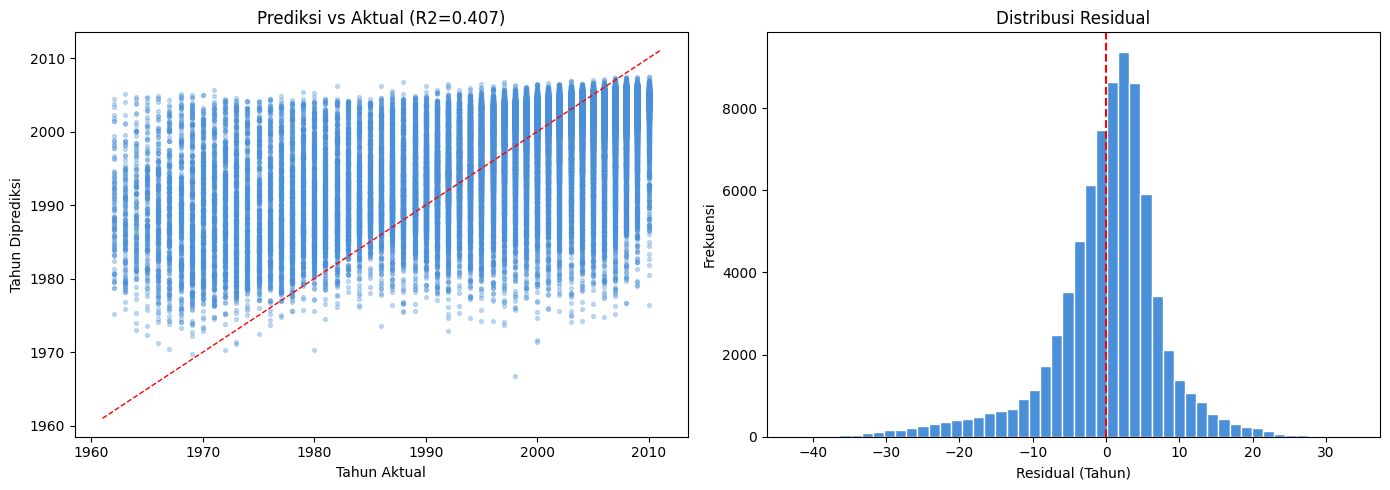

2026/06/23 23:28:58 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/23 23:28:59 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/23 23:29:10 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to m

In [23]:
with mlflow.start_run(run_name="DL_Regression_Final", nested=True):

    test_ds = TensorDataset(torch.from_numpy(X_test_sc), torch.from_numpy(y_test_n))
    test_dl = DataLoader(test_ds, batch_size=bs_best, shuffle=False)

    _, preds_norm = evaluate(model_final, test_dl, criterion_f)

    preds_actual  = preds_norm * y_std + y_mean
    y_test_actual = y_test

    mse  = mean_squared_error(y_test_actual, preds_actual)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_actual, preds_actual)
    r2   = r2_score(y_test_actual, preds_actual)

    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R2   : {r2:.4f}")

    mlflow.log_metrics({"test_mse": mse, "test_rmse": rmse, "test_mae": mae, "test_r2": r2})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_test_actual, preds_actual, alpha=0.3, s=8, color="#4A90D9")
    lim = [min(y_test_actual.min(), preds_actual.min()) - 1,
           max(y_test_actual.max(), preds_actual.max()) + 1]
    axes[0].plot(lim, lim, "r--", lw=1)
    axes[0].set_title(f"Prediksi vs Aktual (R2={r2:.3f})")
    axes[0].set_xlabel("Tahun Aktual")
    axes[0].set_ylabel("Tahun Diprediksi")

    residuals = y_test_actual - preds_actual
    axes[1].hist(residuals, bins=50, color="#4A90D9", edgecolor="white")
    axes[1].axvline(0, color="red", linestyle="--")
    axes[1].set_title("Distribusi Residual")
    axes[1].set_xlabel("Residual (Tahun)")
    axes[1].set_ylabel("Frekuensi")

    plt.tight_layout()
    plt.savefig("evaluation_plots.png", dpi=120)
    mlflow.log_artifact("evaluation_plots.png")
    plt.show()

    mlflow.pytorch.log_model(
        model_final,
        name="model_final",
        serialization_format="pickle"
    )

## Bagian 8: Interpretasi Model dengan LIME

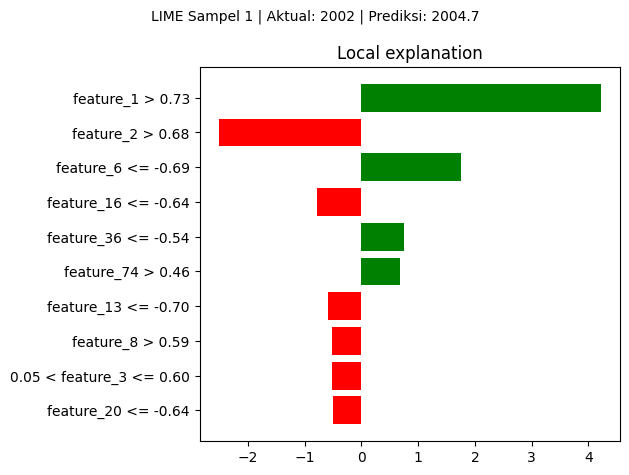


Top 5 Fitur - Sampel 1 (Aktual: 2002, Prediksi: 2004.7):
  feature_1 > 0.73                         -> positif: 4.2209
  feature_2 > 0.68                         -> negatif: -2.5169
  feature_6 <= -0.69                       -> positif: 1.7556
  feature_16 <= -0.64                      -> negatif: -0.7833
  feature_36 <= -0.54                      -> positif: 0.7568


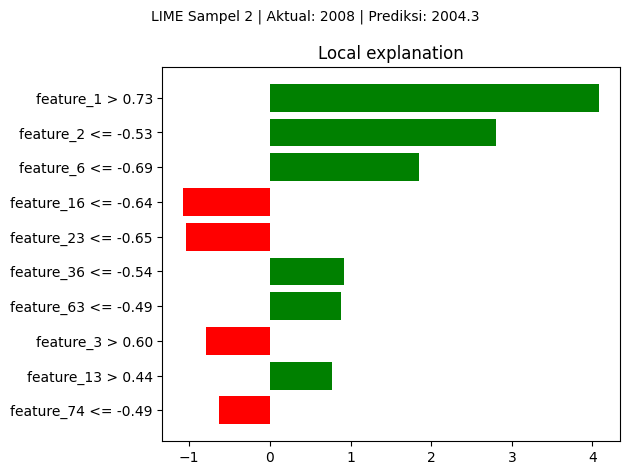


Top 5 Fitur - Sampel 2 (Aktual: 2008, Prediksi: 2004.3):
  feature_1 > 0.73                         -> positif: 4.0834
  feature_2 <= -0.53                       -> positif: 2.7992
  feature_6 <= -0.69                       -> positif: 1.8521
  feature_16 <= -0.64                      -> negatif: -1.0734
  feature_23 <= -0.65                      -> negatif: -1.0395


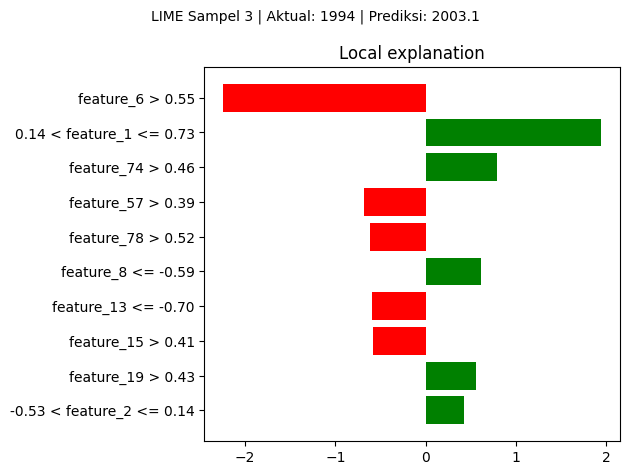


Top 5 Fitur - Sampel 3 (Aktual: 1994, Prediksi: 2003.1):
  feature_6 > 0.55                         -> negatif: -2.2418
  0.14 < feature_1 <= 0.73                 -> positif: 1.9430
  feature_74 > 0.46                        -> positif: 0.7872
  feature_57 > 0.39                        -> negatif: -0.6859
  feature_78 > 0.52                        -> negatif: -0.6173


In [24]:
def model_predict_fn(X_input):
    """Wrapper prediksi dalam skala tahun asli untuk LIME."""
    X_t = torch.from_numpy(X_input.astype(np.float32)).to(DEVICE)
    model_final.eval()
    with torch.no_grad():
        preds_n = model_final(X_t).cpu().numpy()
    return preds_n * y_std + y_mean


explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_sc,
    feature_names = feature_cols,
    mode          = "regression",
    random_state  = 42,
)

LIME_SAMPLES = 3
lime_indices = np.random.RandomState(42).choice(len(X_test_sc), LIME_SAMPLES, replace=False)

with mlflow.start_run(run_name="DL_Regression_Final", nested=True):
    for i, idx in enumerate(lime_indices):
        sample      = X_test_sc[idx]
        actual_year = y_test_actual[idx]
        pred_year   = model_predict_fn(sample.reshape(1, -1))[0]

        explanation = explainer_lime.explain_instance(
            data_row   = sample,
            predict_fn = model_predict_fn,
            num_features = 10,
        )

        fig_lime = explanation.as_pyplot_figure()
        fig_lime.suptitle(
            f"LIME Sampel {i+1} | Aktual: {actual_year:.0f} | Prediksi: {pred_year:.1f}",
            fontsize=10
        )
        plt.tight_layout()
        fname = f"lime_sample_{i+1}.png"
        fig_lime.savefig(fname, dpi=120)
        mlflow.log_artifact(fname)
        plt.show()

        print(f"\nTop 5 Fitur - Sampel {i+1} (Aktual: {actual_year:.0f}, Prediksi: {pred_year:.1f}):")
        for feat_desc, weight in explanation.as_list()[:5]:
            arah = "positif" if weight > 0 else "negatif"
            print(f"  {feat_desc:40s} -> {arah}: {weight:.4f}")

## Ringkasan Hasil

Jalankan cell di bawah untuk melihat ringkasan metrik.

In [25]:
print("=" * 55)
print("RINGKASAN HASIL AKHIR")
print("=" * 55)
print(f"Arsitektur   : {n_layers_best} hidden layers -> {hidden_dims_best}")
print(f"Dropout Rate : {dropout_best:.3f}")
print(f"Learning Rate: {lr_best:.6f}")
print(f"Batch Size   : {bs_best}")
print()
print(f"MSE          : {mse:.4f}")
print(f"RMSE         : {rmse:.4f} tahun")
print(f"MAE          : {mae:.4f} tahun")
print(f"R2 Score     : {r2:.4f}")
print()
print("Interpretasi:")
print(f"  Model memprediksi tahun rilis dengan rata-rata error {rmse:.1f} tahun.")
print(f"  R2={r2:.3f} menunjukkan model menjelaskan {r2*100:.1f}% variansi data test.")
print()
print("Untuk melihat eksperimen MLflow: jalankan `mlflow ui` di terminal.")
print("=" * 55)

RINGKASAN HASIL AKHIR
Arsitektur   : 3 hidden layers -> [256, 64, 128]
Dropout Rate : 0.219
Learning Rate: 0.000445
Batch Size   : 256

MSE          : 60.0564
RMSE         : 7.7496 tahun
MAE          : 5.4352 tahun
R2 Score     : 0.4068

Interpretasi:
  Model memprediksi tahun rilis dengan rata-rata error 7.7 tahun.
  R2=0.407 menunjukkan model menjelaskan 40.7% variansi data test.

Untuk melihat eksperimen MLflow: jalankan `mlflow ui` di terminal.
